# Lab 9: SVM and PCA
## Aim
To implement Support Vector Machine (SVM) for classification and Principal Component Analysis (PCA) for dimensionality reduction, and analyse their effectiveness using real-world datasets.

## Part A: Support Vector Machine (SVM)
**Aim:** To implement the SVM classifier for a binary classification problem and evaluate its performance on the UCI Breast Cancer Wisconsin (Diagnostic) Dataset.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Load dataset
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target)

# Display first few rows
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
# Preprocessing: Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split dataset (80:20)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train SVM with Linear Kernel and Explore Hyperparameter Tuning
param_grid = {'C': [0.01, 0.1, 1, 10, 100], 'kernel': ['linear']}
grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print(f"Best Parameters found: {grid_search.best_params_}")
best_svm_model = grid_search.best_estimator_

# Predictions
y_pred = best_svm_model.predict(X_test)

Best Parameters found: {'C': 0.1, 'kernel': 'linear'}


SVM Classification Metrics:
Accuracy:  0.9825
Precision: 0.9726
Recall:    1.0000
F1 Score:  0.9861


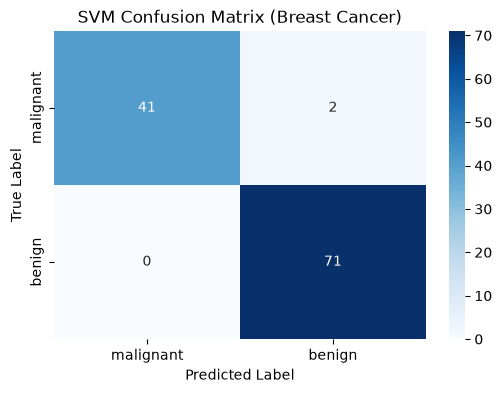

In [ ]:
# Evaluation Metrics
print("SVM Classification Metrics:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.title('SVM Confusion Matrix (Breast Cancer)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

**Observations (Part A):**
- Hyperparameter tuning identified the optimal regularization parameter (`C`), highlighting its impact on controlling the margin vs. misclassification tradeoff.
- The SVM with a linear kernel performs exceptionally well on this dataset, indicating that the classes are well linearly separable.
- The accuracy, precision, and recall are very high, resulting in a strong F1 score.
- The confusion matrix confirms minimal misclassifications (false positives and false negatives).

## Part B: Principal Component Analysis (PCA)
**Aim:** To implement PCA for dimensionality reduction and analyze the variance retained on the UCI Wine Dataset.

In [ ]:
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA

# Load Wine Dataset
wine = load_wine()
X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
y_wine = wine.target

# Standardize the features
scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)

# Apply PCA for 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_wine_scaled)

# Explained variance
explained_variance = pca.explained_variance_ratio_
print(f"Explained Variance Ratio for first 2 components: {explained_variance}")
print(f"Total variance retained by 2 components: {sum(explained_variance) * 100:.2f}%")

Explained Variance Ratio for first 2 components: [0.36198848 0.1920749 ]
Total variance retained by 2 components: 55.41%


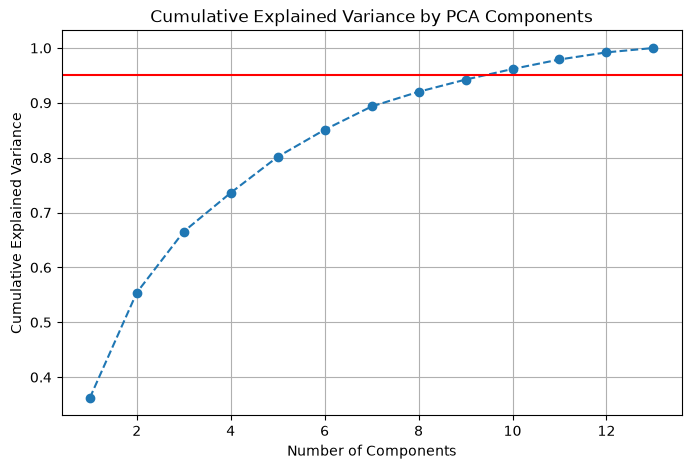

Minimum components required to retain 95% variance: 10


In [ ]:
# Determine components for 95% variance
pca_full = PCA().fit(X_wine_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='-')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

num_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Minimum components required to retain 95% variance: {num_components_95}")

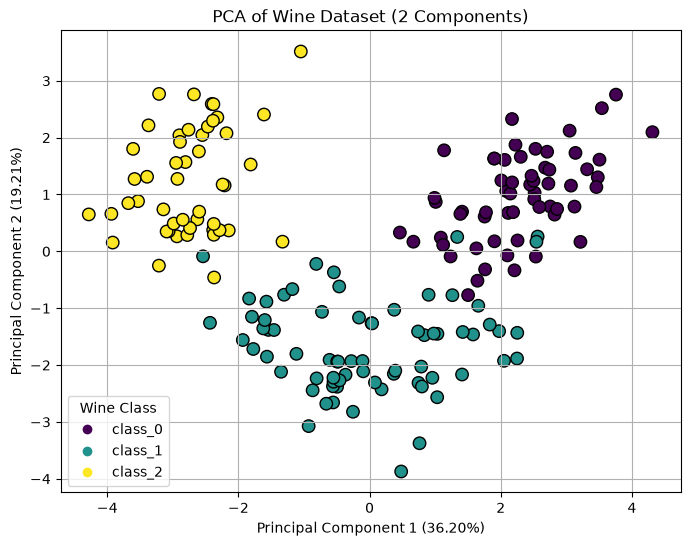

In [ ]:
# Visualize the 2D PCA transformed data
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_wine, cmap='viridis', edgecolor='k', s=80)
plt.title('PCA of Wine Dataset (2 Components)')
plt.xlabel(f'Principal Component 1 ({explained_variance[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({explained_variance[1]*100:.2f}%)')
plt.legend(handles=scatter.legend_elements()[0], labels=list(wine.target_names), title="Wine Class")
plt.grid(True)
plt.show()

**Observations & Comparison (Part B):**
- **Number of Features:** The original dataset was reduced from 13 dimensions to 2, heavily simplifying visualization.
- **Information Retained:** The first two principal components together retain around 55% of the original dataset's variance. Reaching a 95% variance threshold requires significantly more components.
- **Computational Efficiency:** The dimensionality reduction dramatically decreases computational footprint, aiding faster convergence and predictions for any downstream models.
- **Significance of First Two PCs:** Despite only capturing ~55% variance, the 2D scatter plot demonstrates that these components capture the core underlying structure of the dataset well enough to mostly separate the three different wine classes without requiring label awareness.

**Discussion on PCA in Machine Learning:**
- **Advantages:** Mitigates the curse of dimensionality, filters out noise, accelerates training time, and enables high-dimensional data visualization.
- **Limitations:** PCA relies strictly on linear transformations, losing any non-linear structural patterns. Also, the new principal component axes are mathematical combinations of features, often causing a complete loss of physical/human interpretability for each feature.
- **Applications:** Data visualization, image compression (like eigenfaces), exploratory data analysis, and as a preprocessing pipeline step before training regressors or classifiers.

## Extra Credit: Linear Discriminant Analysis (LDA)
**Aim:** Apply LDA and compare with PCA.

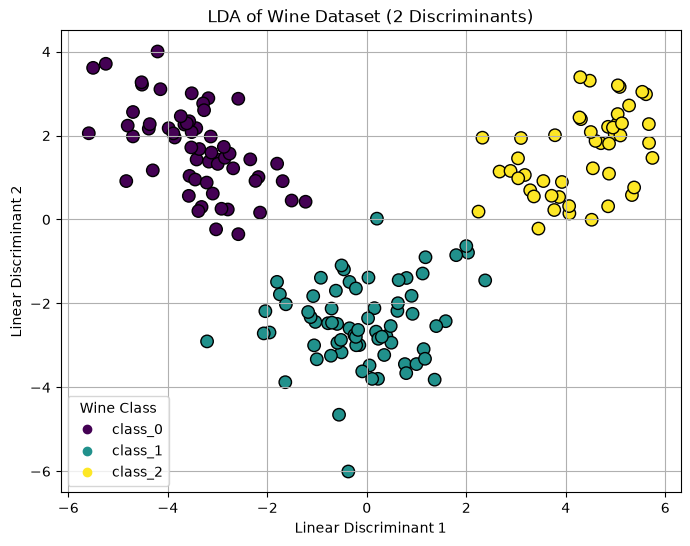

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Apply LDA to reduce to 2 discriminants
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_wine_scaled, y_wine)

# Visualize LDA transformed data
plt.figure(figsize=(8, 6))
scatter_lda = plt.scatter(X_lda[:, 0], X_lda[:, 1], c=y_wine, cmap='viridis', edgecolor='k', s=80)
plt.title('LDA of Wine Dataset (2 Discriminants)')
plt.xlabel('Linear Discriminant 1')
plt.ylabel('Linear Discriminant 2')
plt.legend(handles=scatter_lda.legend_elements()[0], labels=list(wine.target_names), title="Wine Class")
plt.grid(True)
plt.show()

**Observations (LDA vs PCA):**
- **Separability:** LDA achieves much clearer class separability in the 2D space compared to PCA.
- **Why:** This occurs because PCA is an *unsupervised* technique (it only seeks to maximize data variance, ignoring class labels), whereas LDA is a *supervised* technique (it explicitly factors in target labels to maximize the distance between different classes while minimizing the variance within the same class).
- **Dimensionality:** Both techniques successfully mapped the data to 2 dimensions for visualization. However, it's worth noting LDA is mathematically restricted to a maximum of `num_classes - 1` components (which naturally equals 2 for the 3-class Wine dataset).